In [2]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter

from utils.jupyter_utils import ImageLinePlotter
%matplotlib inline


#  2007_000032.png
PIL values: [  0   1  15 255]
cv2 values: [  0 128 192 224]


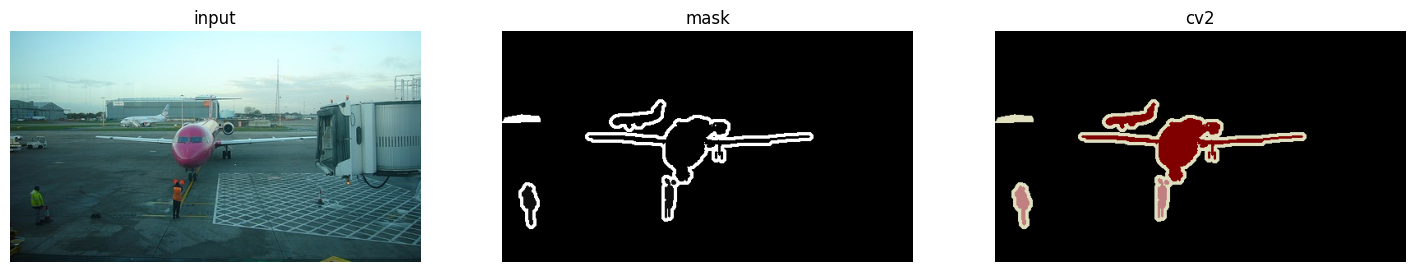

#  2007_000033.png
PIL values: [  0   1 255]
cv2 values: [  0 128 192 224]


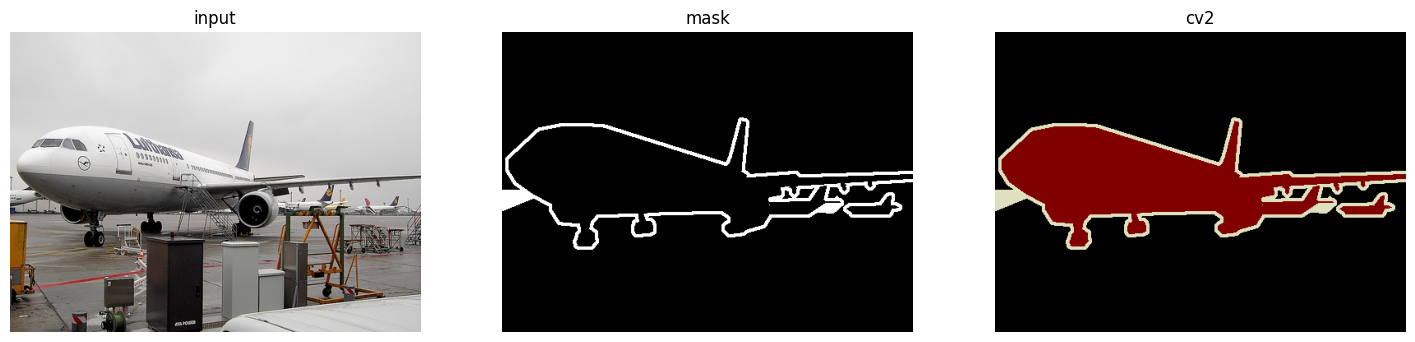

#  2007_000039.png
PIL values: [  0  20 255]
cv2 values: [  0  64 128 192 224]


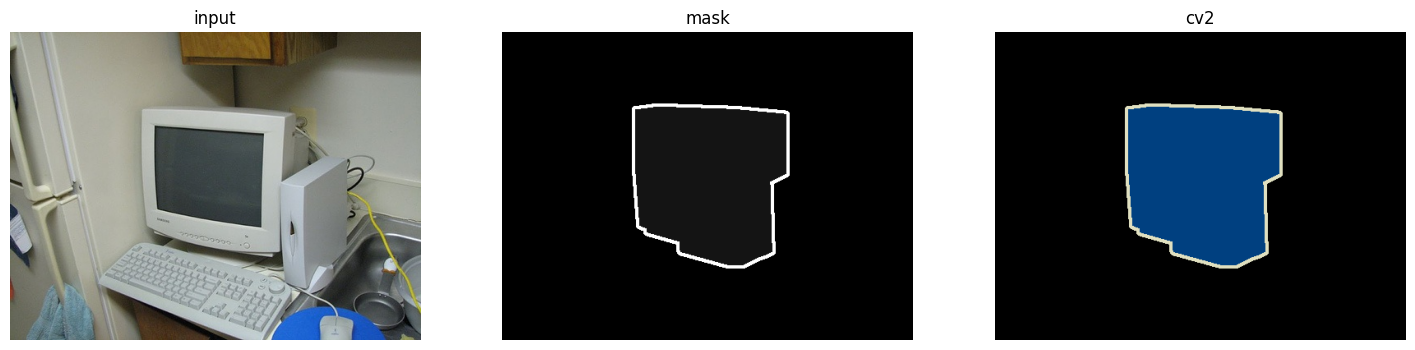

#  2007_000042.png
PIL values: [  0  19 255]
cv2 values: [  0 128 192 224]


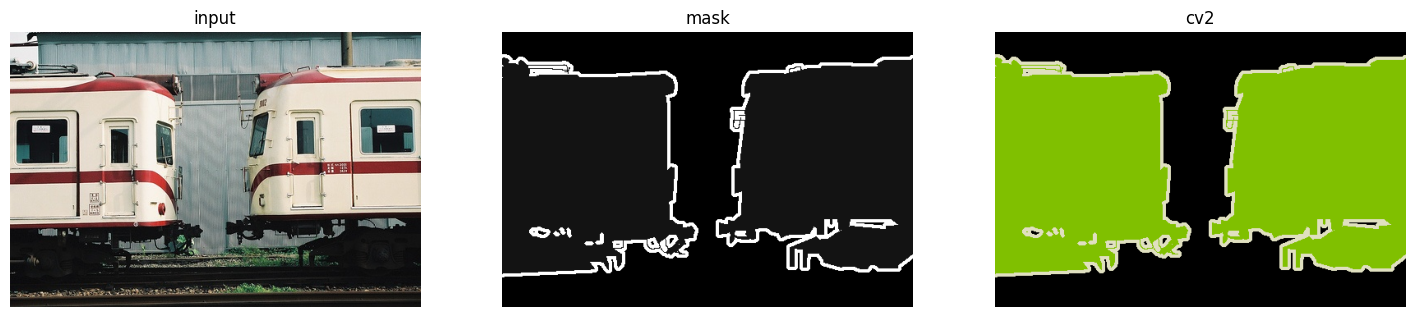

#  2007_000061.png
PIL values: [  0   4 255]
cv2 values: [  0 128 192 224]


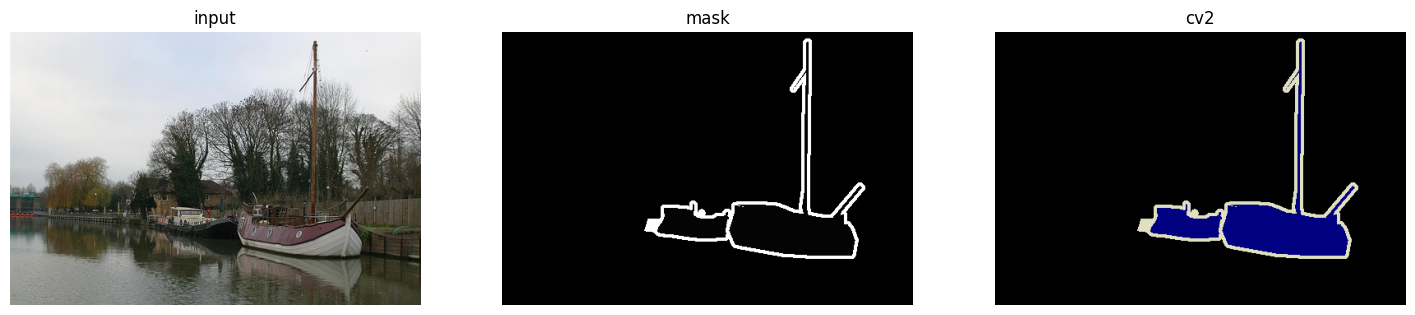

In [5]:
ORG_DIR = os.path.join('.','VOC2012', 'JPEGImages')
SEG_DIR = os.path.join('.','VOC2012', 'SegmentationClass')

segs = glob.glob(os.path.join(SEG_DIR, '*.png'))
segs.sort()

for seg_file in segs[:5]:
    print('# ', os.path.basename(seg_file))
    fname , _ = os.path.splitext(os.path.basename(seg_file))
    org_file = os.path.join(ORG_DIR, fname + '.jpg')
    if not os.path.exists(org_file):
        print('not found: ', org_file)
    org_img = cv2.imread(org_file)
    seg_img_PIL = np.array(Image.open(seg_file))
    seg_img_cv2 = cv2.imread(seg_file)

    print('PIL values:', np.unique(seg_img_PIL))
    print('cv2 values:', np.unique(seg_img_cv2))

    plotter = ImageLinePlotter(plot_area_num=3)
    plotter.add_image(org_img, title='input')
    plotter.add_image(seg_img_PIL, title='mask')
    plotter.add_image(seg_img_cv2, title='cv2')
    plotter.show_plot()



In [13]:
import shutil

TARGET_DIR = os.path.join('.', 'target_data')

ID_PERSON = 15
ID_CAT = 8
ID_DOG = 12

cls_counters = {}
for seg_file in segs:
    seg_img_PIL = np.array(Image.open(seg_file))

    copy_to = ''
    if np.any(seg_img_PIL == ID_PERSON):
        copy_to += 'person_'
    if np.any(seg_img_PIL == ID_CAT):
        copy_to += 'cat_'
    if np.any(seg_img_PIL == ID_DOG):
        copy_to += 'dog_'

    if copy_to == '':
        continue

    if not copy_to in cls_counters.keys():
        cls_counters[copy_to] = 0
    cls_counters[copy_to] += 1

    copy_path = os.path.join(TARGET_DIR, copy_to)
    if not os.path.exists(copy_path):
        os.makedirs(copy_path)
    shutil.copy(seg_file, copy_path)

print(cls_counters)

{'person_': 818, 'dog_': 190, 'cat_': 225, 'person_cat_': 18, 'person_dog_': 52, 'cat_dog_': 7}
